In [397]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import roc_auc_score

In [398]:
root_path = "/home/stefan/ioai-prep/kits/ojia-2026/nurse"

seed = 42

# Subtask 1

In [399]:
df_train = pd.read_csv(f"{root_path}/train_data.csv")

In [400]:
subtask1 = [df_train["day_28_flg"].isna().sum()]
subtask1

[1235]

In [401]:
f"{subtask1[0] / len(df_train) * 100:.2f}% missing"

'92.51% missing'

# Subtask 2

In [402]:
labeled_df = df_train.dropna(subset=["day_28_flg"])

sofa_gt10_mask = labeled_df["sofa_first"] > 10
sofa_le10_mask = labeled_df["sofa_first"] <= 10

mortality_gt10 = labeled_df[sofa_gt10_mask]["day_28_flg"].mean() * 100
mortality_le10 = labeled_df[sofa_le10_mask]["day_28_flg"].mean() * 100

In [ ]:
subtask2 = [mortality_gt10, mortality_le10]
subtask2

[0.0, 5102.040816326531]

# Subtask 3

## Data

In [404]:
def prep_df(df: pd.DataFrame):
    df = df.drop(["ID"], axis=1, errors='ignore')

    # df = df.dropna(axis=1)
    df = df.select_dtypes(exclude='object')

    columns = [c for c in df.columns if c != "day_28_flg"]
    return df, columns

In [405]:
train_feats, features = prep_df(df_train)
train_feats.head()

,aline_flg,age,gender_num,weight_first,bmi,sapsi_first,sofa_first,service_num,day_icu_intime_num,hour_icu_intime,...,platelet_first,sodium_first,potassium_first,tco2_first,chloride_first,bun_first,creatinine_first,po2_first,pco2_first,iv_day_1
0,1,72.36841,1.0,75.0,29.912791,15,9,1,6,6,...,354.0,138.0,4.6,15.0,109.0,41.0,1.6,196.0,39.0,2230.875000
1,0,48.40044,0.0,NaN,NaN,14,5,0,2,4,...,367.0,133.0,3.7,19.0,98.0,25.0,0.9,473.0,32.0,2850.000000
2,1,48.97547,1.0,97.0,31.579563,13,11,1,5,2,...,145.0,133.0,4.0,31.0,95.0,18.0,1.0,493.0,34.0,3682.880127
3,1,60.37829,0.0,51.0,25.207321,18,7,1,7,22,...,200.0,144.0,3.2,20.0,120.0,13.0,0.7,473.0,34.0,213.119995
4,1,83.20917,1.0,76.4,26.060587,18,5,1,3,0,...,249.0,137.0,4.8,19.0,104.0,29.0,2.0,251.0,35.0,NaN


In [406]:
scaler = StandardScaler()

train_feats = scaler.fit_transform(train_feats[features])

In [407]:
train_for_imp = pd.DataFrame(train_feats, columns=features)
train_for_imp["day_28_flg"] = df_train["day_28_flg"].values

imputer = KNNImputer(n_neighbors=10)
train_imputed = imputer.fit_transform(train_for_imp)

train_targets = train_imputed[:, -1]
train_targets = (train_targets > 0.5).astype(int)
train_imputed = train_imputed[:, :-1]

In [408]:
X_train, X_test, y_train, y_test = train_test_split(train_feats, train_targets, test_size=0.2, random_state=seed)

## Model

In [409]:
def evaluate(clf):
    cv = cross_val_score(clf, X_train, y_train, cv=3, scoring="roc_auc")
    cv = cv.mean() - cv.std()

    clf.fit(X_train, y_train)
    preds = clf.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, preds), cv

In [410]:
rf = RandomForestClassifier(n_estimators=500, max_depth=5, class_weight="balanced", random_state=seed)

evaluate(rf)

(0.9515910629654706, 0.9259299381223671)

## Predictions

In [411]:
df_test = pd.read_csv(f"{root_path}/test_data.csv")
test_feats, _ = prep_df(df_test)
test_feats = scaler.transform(test_feats[features])

In [412]:
subtask3 = rf.predict_proba(test_feats)[:, 1]

<Axes: ylabel='Count'>

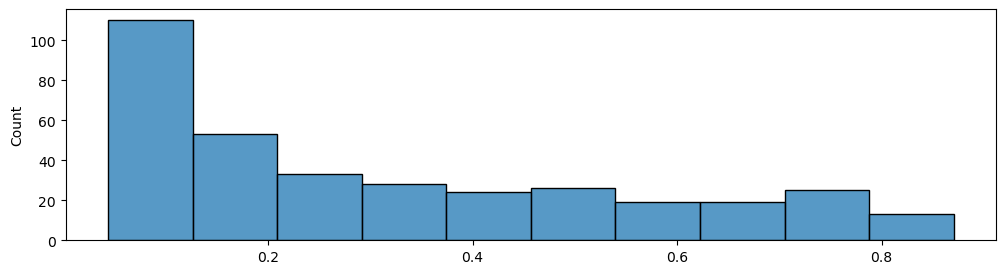

In [413]:
plt.figure(figsize=(12,3))
sns.histplot(subtask3)

# Submission

In [414]:
def build_submission(sid, ans):
    id_ = df_test["ID"] if sid == 3 else 1
    if sid == 2:
        id_ = [1, 2]
    return pd.DataFrame({"datapointID": id_, "subtaskID": sid, "answer": ans})

In [415]:
subtasks = [
    (1, subtask1),
    (2, subtask2),
    (3, subtask3)
]

sub = pd.concat([build_submission(sid, ans) for sid, ans in subtasks])

In [416]:
sub.head()

,datapointID,subtaskID,answer
0,1,1,1235.000000
0,1,2,0.000000
1,2,2,5102.040816
0,0,3,0.148890
1,1,3,0.690746


In [417]:
sub.to_csv(f"{root_path}/submission.csv", index=False)